In [1]:
%pip install pandas numpy nltk scikit-learn matplotlib seaborn

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [2]:
import os
import zipfile
import string

import numpy as np
import pandas as pd
import nltk

import matplotlib.pyplot as plt
import seaborn as sns

from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

print("All libraries imported successfully.")

All libraries imported successfully.


In [3]:
nltk.download("stopwords")

stop_words = set(stopwords.words("english"))
stemmer = PorterStemmer()

print("Number of English stopwords:", len(stop_words))

Number of English stopwords: 198


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\hp\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [4]:
current_folder = os.getcwd()

zip_path = os.path.join(
    current_folder,
    "sms+spam+collection.zip"
)

if not os.path.exists(zip_path):
    raise FileNotFoundError(
        "sms+spam+collection.zip was not found. "
        "Place it in the same folder as this notebook."
    )

extract_folder = os.path.join(
    current_folder,
    "sms_spam_dataset"
)

os.makedirs(
    extract_folder,
    exist_ok=True
)

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_folder)

print("ZIP file extracted successfully.")
print("Files found:")
print(os.listdir(extract_folder))

ZIP file extracted successfully.
Files found:
['readme', 'SMSSpamCollection']


In [5]:
dataset_file = os.path.join(
    extract_folder,
    "SMSSpamCollection"
)

if not os.path.exists(dataset_file):
    raise FileNotFoundError(
        "SMSSpamCollection file was not found."
    )

df = pd.read_csv(
    dataset_file,
    sep="\t",
    header=None,
    names=["label", "text"]
)

print("Dataset loaded successfully.")
print("Number of records:", len(df))

Dataset loaded successfully.
Number of records: 5572


In [6]:
print("Dataset shape:")
print(df.shape)

print("\nClass distribution:")
print(df["label"].value_counts())

Dataset shape:
(5572, 2)

Class distribution:
label
ham     4825
spam     747
Name: count, dtype: int64


In [7]:
print("Missing values:")
print(df.isnull().sum())

Missing values:
label    0
text     0
dtype: int64


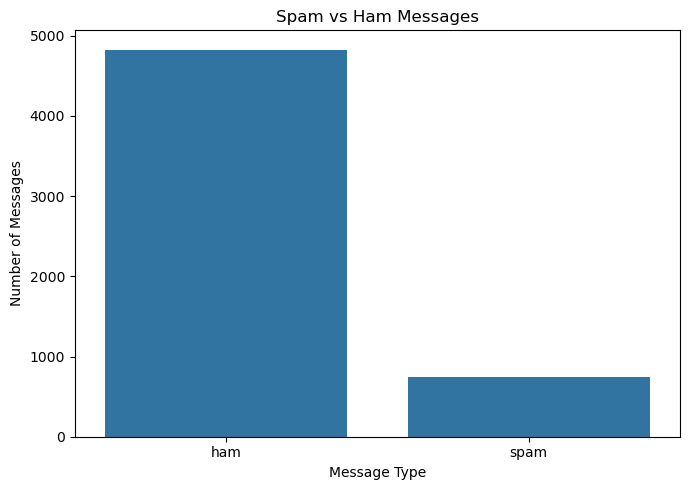

In [8]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="label"
)

plt.title("Spam vs Ham Messages")
plt.xlabel("Message Type")
plt.ylabel("Number of Messages")

plt.tight_layout()
plt.show()

In [9]:
print("===== 5 SPAM MESSAGES =====")

spam_messages = df[
    df["label"] == "spam"
]["text"].head(5)

for i, message in enumerate(
    spam_messages,
    1
):
    print(f"\n{i}. {message}")

===== 5 SPAM MESSAGES =====

1. Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entry question(std txt rate)T&C's apply 08452810075over18's

2. FreeMsg Hey there darling it's been 3 week's now and no word back! I'd like some fun you up for it still? Tb ok! XxX std chgs to send, £1.50 to rcv

3. WINNER!! As a valued network customer you have been selected to receivea £900 prize reward! To claim call 09061701461. Claim code KL341. Valid 12 hours only.

4. Had your mobile 11 months or more? U R entitled to Update to the latest colour mobiles with camera for Free! Call The Mobile Update Co FREE on 08002986030

5. SIX chances to win CASH! From 100 to 20,000 pounds txt> CSH11 and send to 87575. Cost 150p/day, 6days, 16+ TsandCs apply Reply HL 4 info


In [11]:
print("===== 5 HAM MESSAGES =====")

ham_messages = df[
    df["label"] == "ham"
]["text"].head(5)

for i, message in enumerate(
    ham_messages,
    1
):
    print(f"\n{i}. {message}")

===== 5 HAM MESSAGES =====

1. Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...

2. Ok lar... Joking wif u oni...

3. U dun say so early hor... U c already then say...

4. Nah I don't think he goes to usf, he lives around here though

5. Even my brother is not like to speak with me. They treat me like aids patent.


In [12]:
def clean_text(text):

    # Convert to lowercase
    text = str(text).lower()

    # Remove punctuation
    text = text.translate(
        str.maketrans(
            "",
            "",
            string.punctuation
        )
    )

    # Split into words
    words = text.split()

    # Remove stopwords
    words = [
        word
        for word in words
        if word not in stop_words
    ]

    # Apply stemming
    words = [
        stemmer.stem(word)
        for word in words
    ]

    # Join words again
    return " ".join(words)

In [13]:
sample_text = (
    "Congratulations! You are running "
    "to WIN a FREE prize."
)

print("Original text:")
print(sample_text)

print("\nCleaned text:")
print(clean_text(sample_text))

Original text:
Congratulations! You are running to WIN a FREE prize.

Cleaned text:
congratul run win free prize


In [14]:
df["clean_text"] = df["text"].apply(
    clean_text
)

print("Text preprocessing completed.")

Text preprocessing completed.


In [15]:
X = df["clean_text"]
y = df["label"]

print("Input samples:", len(X))
print("Target samples:", len(y))

Input samples: 5572
Target samples: 5572


In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples :", len(X_test))

Training samples: 4457
Testing samples : 1115


In [17]:
tfidf = TfidfVectorizer()

X_train_tfidf = tfidf.fit_transform(
    X_train
)

X_test_tfidf = tfidf.transform(
    X_test
)

print(
    "Training TF-IDF shape:",
    X_train_tfidf.shape
)

print(
    "Testing TF-IDF shape:",
    X_test_tfidf.shape
)

print(
    "Vocabulary size:",
    len(tfidf.get_feature_names_out())
)

Training TF-IDF shape: (4457, 7118)
Testing TF-IDF shape: (1115, 7118)
Vocabulary size: 7118


In [18]:
feature_names = np.array(
    tfidf.get_feature_names_out()
)

y_train_reset = y_train.reset_index(
    drop=True
)

spam_indices = np.where(
    y_train_reset.values == "spam"
)[0]

spam_tfidf = X_train_tfidf[
    spam_indices
]

mean_spam_scores = np.asarray(
    spam_tfidf.mean(axis=0)
).ravel()

top_indices = (
    mean_spam_scores
    .argsort()[-20:][::-1]
)

print(
    "===== TOP 20 SPAM-ASSOCIATED WORDS ====="
)

for rank, index in enumerate(
    top_indices,
    1
):

    print(
        f"{rank:2}. "
        f"{feature_names[index]:20} "
        f"{mean_spam_scores[index]:.6f}"
    )

===== TOP 20 SPAM-ASSOCIATED WORDS =====
 1. call                 0.061350
 2. free                 0.044729
 3. txt                  0.034426
 4. claim                0.030044
 5. mobil                0.028793
 6. text                 0.027447
 7. ur                   0.026127
 8. stop                 0.025605
 9. repli                0.025522
10. prize                0.023871
11. servic               0.022472
12. urgent               0.018957
13. contact              0.017885
14. nokia                0.017796
15. new                  0.017695
16. cash                 0.017547
17. award                0.017396
18. win                  0.016765
19. tone                 0.016580
20. pleas                0.016237


In [19]:
nb_model = MultinomialNB()

nb_model.fit(
    X_train_tfidf,
    y_train
)

nb_predictions = nb_model.predict(
    X_test_tfidf
)

print(
    "Multinomial Naive Bayes "
    "training completed."
)

Multinomial Naive Bayes training completed.


In [20]:
nb_accuracy = accuracy_score(
    y_test,
    nb_predictions
)

nb_precision = precision_score(
    y_test,
    nb_predictions,
    pos_label="spam",
    zero_division=0
)

nb_recall = recall_score(
    y_test,
    nb_predictions,
    pos_label="spam",
    zero_division=0
)

nb_f1 = f1_score(
    y_test,
    nb_predictions,
    pos_label="spam",
    zero_division=0
)

print("===== NAIVE BAYES RESULTS =====")

print(
    f"Accuracy : "
    f"{nb_accuracy * 100:.2f}%"
)

print(
    f"Precision: "
    f"{nb_precision * 100:.2f}%"
)

print(
    f"Recall   : "
    f"{nb_recall * 100:.2f}%"
)

print(
    f"F1 Score : "
    f"{nb_f1 * 100:.2f}%"
)

===== NAIVE BAYES RESULTS =====
Accuracy : 96.41%
Precision: 100.00%
Recall   : 73.15%
F1 Score : 84.50%


In [21]:
print("===== NAIVE BAYES CLASSIFICATION REPORT =====")

print(
    classification_report(
        y_test,
        nb_predictions,
        zero_division=0
    )
)

===== NAIVE BAYES CLASSIFICATION REPORT =====
              precision    recall  f1-score   support

         ham       0.96      1.00      0.98       966
        spam       1.00      0.73      0.84       149

    accuracy                           0.96      1115
   macro avg       0.98      0.87      0.91      1115
weighted avg       0.97      0.96      0.96      1115



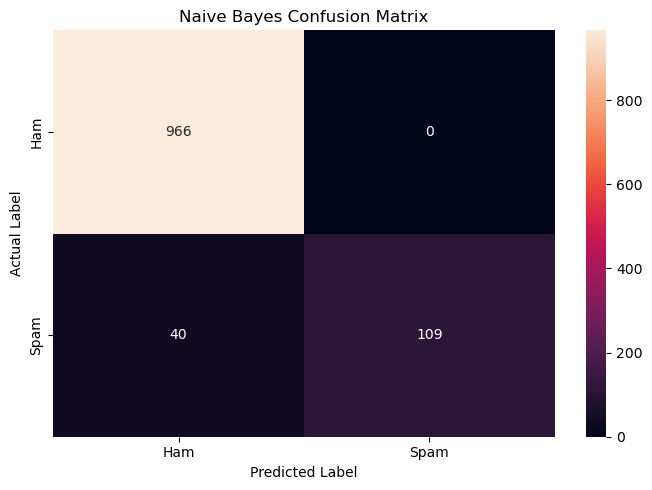

In [22]:
cm_nb = confusion_matrix(
    y_test,
    nb_predictions,
    labels=["ham", "spam"]
)

plt.figure(
    figsize=(7, 5)
)

sns.heatmap(
    cm_nb,
    annot=True,
    fmt="d",
    xticklabels=[
        "Ham",
        "Spam"
    ],
    yticklabels=[
        "Ham",
        "Spam"
    ]
)

plt.title(
    "Naive Bayes Confusion Matrix"
)

plt.xlabel(
    "Predicted Label"
)

plt.ylabel(
    "Actual Label"
)

plt.tight_layout()
plt.show()

In [23]:
results_nb = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": nb_predictions,
    "Message": df.loc[
        y_test.index,
        "text"
    ].values
})

missed_spam = results_nb[
    (results_nb["Actual"] == "spam") &
    (results_nb["Predicted"] == "ham")
]

print(
    "Number of missed spam messages:",
    len(missed_spam)
)

for i, message in enumerate(
    missed_spam["Message"],
    1
):

    print(
        f"\n{i}. {message}"
    )

Number of missed spam messages: 40

1. You are now unsubscribed all services. Get tons of sexy babes or hunks straight to your phone! go to http://gotbabes.co.uk. No subscriptions.

2. FreeMsg Hey there darling it's been 3 week's now and no word back! I'd like some fun you up for it still? Tb ok! XxX std chgs to send, £1.50 to rcv

3. Guess what! Somebody you know secretly fancies you! Wanna find out who it is? Give us a call on 09065394514 From Landline DATEBox1282EssexCM61XN 150p/min 18

4. Dear Voucher Holder 2 claim your 1st class airport lounge passes when using Your holiday voucher call 08704439680. When booking quote 1st class x 2

5. Talk sexy!! Make new friends or fall in love in the worlds most discreet text dating service. Just text VIP to 83110 and see who you could meet.

6. sexy sexy cum and text me im wet and warm and ready for some porn! u up for some fun? THIS MSG IS FREE RECD MSGS 150P INC VAT 2 CANCEL TEXT STOP

7. Hi if ur lookin 4 saucy daytime fun wiv busty marrie

In [24]:
lr_model = LogisticRegression(
    max_iter=1000
)

lr_model.fit(
    X_train_tfidf,
    y_train
)

lr_predictions = lr_model.predict(
    X_test_tfidf
)

print(
    "Logistic Regression "
    "training completed."
)

Logistic Regression training completed.


In [25]:
lr_accuracy = accuracy_score(
    y_test,
    lr_predictions
)

lr_precision = precision_score(
    y_test,
    lr_predictions,
    pos_label="spam",
    zero_division=0
)

lr_recall = recall_score(
    y_test,
    lr_predictions,
    pos_label="spam",
    zero_division=0
)

lr_f1 = f1_score(
    y_test,
    lr_predictions,
    pos_label="spam",
    zero_division=0
)

print(
    "===== LOGISTIC REGRESSION RESULTS ====="
)

print(
    f"Accuracy : "
    f"{lr_accuracy * 100:.2f}%"
)

print(
    f"Precision: "
    f"{lr_precision * 100:.2f}%"
)

print(
    f"Recall   : "
    f"{lr_recall * 100:.2f}%"
)

print(
    f"F1 Score : "
    f"{lr_f1 * 100:.2f}%"
)

===== LOGISTIC REGRESSION RESULTS =====
Accuracy : 96.14%
Precision: 100.00%
Recall   : 71.14%
F1 Score : 83.14%


In [26]:
print(
    "===== LOGISTIC REGRESSION "
    "CLASSIFICATION REPORT ====="
)

print(
    classification_report(
        y_test,
        lr_predictions,
        zero_division=0
    )
)

===== LOGISTIC REGRESSION CLASSIFICATION REPORT =====
              precision    recall  f1-score   support

         ham       0.96      1.00      0.98       966
        spam       1.00      0.71      0.83       149

    accuracy                           0.96      1115
   macro avg       0.98      0.86      0.90      1115
weighted avg       0.96      0.96      0.96      1115



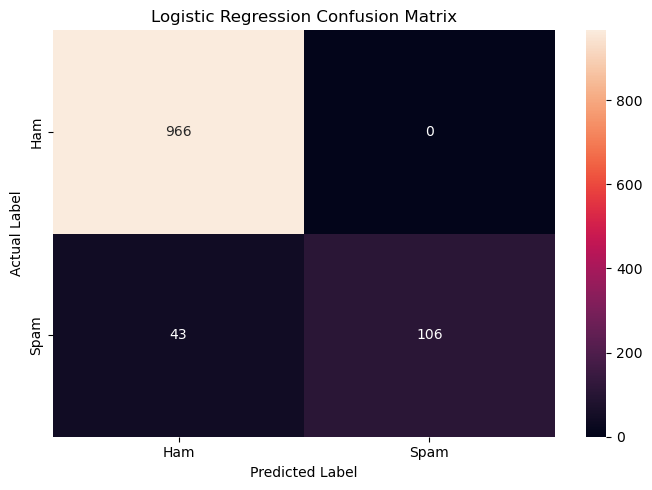

In [27]:
cm_lr = confusion_matrix(
    y_test,
    lr_predictions,
    labels=["ham", "spam"]
)

plt.figure(
    figsize=(7, 5)
)

sns.heatmap(
    cm_lr,
    annot=True,
    fmt="d",
    xticklabels=[
        "Ham",
        "Spam"
    ],
    yticklabels=[
        "Ham",
        "Spam"
    ]
)

plt.title(
    "Logistic Regression Confusion Matrix"
)

plt.xlabel(
    "Predicted Label"
)

plt.ylabel(
    "Actual Label"
)

plt.tight_layout()
plt.show()

In [28]:
comparison = pd.DataFrame({

    "Model": [
        "Multinomial Naive Bayes",
        "Logistic Regression"
    ],

    "Accuracy (%)": [
        nb_accuracy * 100,
        lr_accuracy * 100
    ],

    "Precision (%)": [
        nb_precision * 100,
        lr_precision * 100
    ],

    "Recall (%)": [
        nb_recall * 100,
        lr_recall * 100
    ],

    "F1 Score (%)": [
        nb_f1 * 100,
        lr_f1 * 100
    ]
})

display(
    comparison.round(2)
)

,Model,Accuracy (%),Precision (%),Recall (%),F1 Score (%)
0,Multinomial Naive Bayes,96.41,100.0,73.15,84.50
1,Logistic Regression,96.14,100.0,71.14,83.14


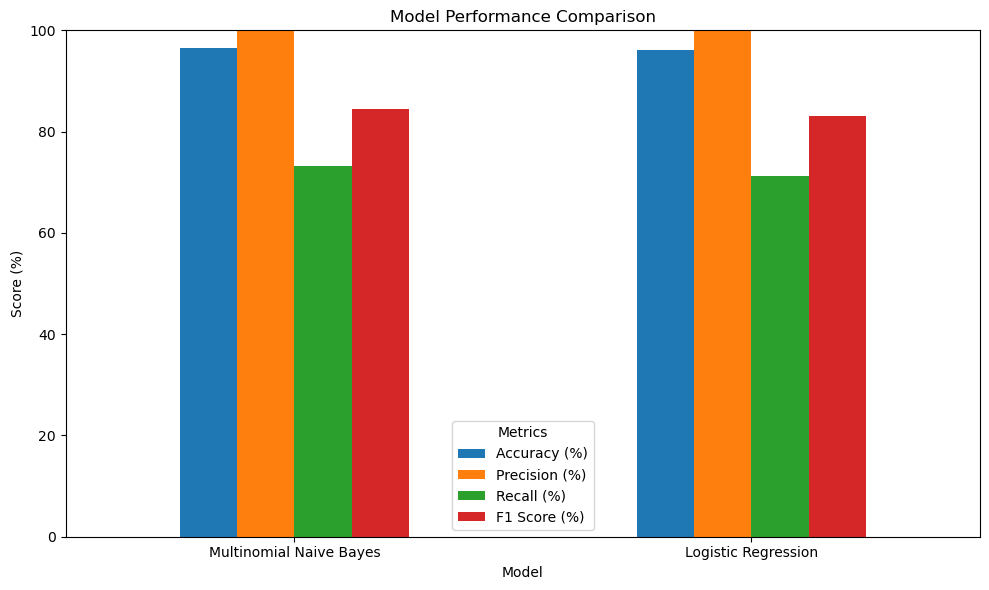

In [29]:
comparison_plot = comparison.set_index(
    "Model"
)

comparison_plot.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title(
    "Model Performance Comparison"
)

plt.ylabel(
    "Score (%)"
)

plt.xlabel(
    "Model"
)

plt.ylim(
    0,
    100
)

plt.xticks(
    rotation=0
)

plt.legend(
    title="Metrics"
)

plt.tight_layout()
plt.show()

In [33]:
def predict_spam(text):

    # Clean the raw message
    cleaned_text = clean_text(
        text
    )

    # Convert to TF-IDF
    text_tfidf = tfidf.transform(
        [cleaned_text]
    )

    # Predict class
    prediction = nb_model.predict(
        text_tfidf
    )[0]

    # Get probabilities
    probabilities = (
        nb_model.predict_proba(
            text_tfidf
        )[0]
    )

    # Find probability of predicted class
    class_index = list(
        nb_model.classes_
    ).index(
        prediction
    )

    confidence = probabilities[
        class_index
    ]

    return (
        prediction.upper(),
        confidence * 100
    )

In [35]:
print("===== ENTER 5 MESSAGES =====")

for i in range(1, 6):

    user_message = input(
        f"\nEnter message {i}: "
    )

    prediction, confidence = predict_spam(
        user_message
    )

    print("\n--- Result ---")
    print("Message:", user_message)
    print("Prediction:", prediction)
    print(f"Confidence: {confidence:.2f}%")

===== ENTER 5 MESSAGES =====



Enter message 1:  Hello! How are you?



--- Result ---
Message: Hello! How are you?
Prediction: HAM
Confidence: 95.69%



Enter message 2:  I have sent an OTP. Please share with me.



--- Result ---
Message: I have sent an OTP. Please share with me.
Prediction: HAM
Confidence: 94.94%


...


--- Result ---
Message: URGENT! You have won $5000 cash. Call now to claim your reward.
Prediction: SPAM
Confidence: 94.05%



Enter message 4:  Congratulations! Your mobile number has won a cash prize of $10,000. Claim immediately.



--- Result ---
Message: Congratulations! Your mobile number has won a cash prize of $10,000. Claim immediately.
Prediction: SPAM
Confidence: 95.33%



Enter message 5:  Your account has been selected for a limited-time reward. Click the link to receive your bonus.



--- Result ---
Message: Your account has been selected for a limited-time reward. Click the link to receive your bonus.
Prediction: SPAM
Confidence: 80.77%
